In [1]:
# ============================================================
# === FLOATS MC-ENSEMBLE FLUX WITH UNCERTAINTY PROPAGATION ===
# === Mirrors SOCAT ± sigma methodology (FINAL VERSION)     ===
# ============================================================

import pandas as pd
import numpy as np
import pyseaflux
import matplotlib.pyplot as plt

# ============================================================
# 1) LOAD DATA
# ============================================================

predictions_floats = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_FLOATS_only_MCensemble.csv"
)

# REMOVE FEB 2023 FROM PREDICTIONS
predictions_floats["month_center"] = pd.to_datetime(predictions_floats["month_center"])
predictions_floats = predictions_floats[
    ~((predictions_floats["month_center"].dt.year == 2023) &
      (predictions_floats["month_center"].dt.month == 2))
]

floats_df = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/BGC-Argo_SO_feature_engineered_monthly_1deg.csv",
    low_memory=False
)

# Rename observed pCO2 to match predictor format
floats_df.rename(columns={"pco2": "FLOATS_pco2_median"}, inplace=True)

# ============================================================
# 2) OBSERVATION UNCERTAINTY (± observational sigma)
# ============================================================

floats_df_low  = floats_df.copy()
floats_df_high = floats_df.copy()

floats_df_low["FLOATS_pco2_median"]  -= floats_df_low["FLOATS_pco2_error_median"]
floats_df_high["FLOATS_pco2_median"] += floats_df_high["FLOATS_pco2_error_median"]

# ============================================================
# 3) MODEL ENSEMBLE UNCERTAINTY (from MC ensemble)
# ============================================================

pred_low  = predictions_floats.copy()
pred_high = predictions_floats.copy()

sigma_model = predictions_floats["ensemble_pco2_std"].values

pred_low["ensemble_pco2_pred"]  = predictions_floats["ensemble_pco2_pred"] - sigma_model
pred_high["ensemble_pco2_pred"] = predictions_floats["ensemble_pco2_pred"] + sigma_model

# ============================================================
# 4) FLUX FUNCTIONS
# ============================================================

def flux_from_pco2(df, pco2_sw):
    wind_speed = df["wind_speed"].values
    temp_C     = df["FLOATS_temperature_median"].values
    salinity   = df["FLOATS_salinity_median"].values
    pco2_air   = df["atm_co2"].values
    pres_hPa   = 1013.25

    k_w = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)

    flux_mol = pyseaflux.flux_calculations.flux_bulk(
        temp_C, salinity, pco2_sw, pco2_air, pres_hPa, k_w
    )
    return flux_mol * 12.01   # g C m^-2 day^-1


def compute_flux_obs(df):
    return flux_from_pco2(df, df["FLOATS_pco2_median"].values)


def compute_flux_pred(df):
    return flux_from_pco2(df, df["ensemble_pco2_pred"].values)

# ============================================================
# 5) BINNING + AREA WEIGHTING (same as SOCAT)
# ============================================================

def bin_flux(df, lat_col, lon_col, time_col, flux_col):
    df = df.copy()
    df["lat_bin"] = df[lat_col].astype(int)
    df["lon_bin"] = df[lon_col].astype(int)
    df["year"]    = df[time_col].dt.year
    df["month"]   = df[time_col].dt.month

    return (
        df.groupby(["lat_bin", "lon_bin", "year", "month"])[flux_col]
        .mean()
        .reset_index(name="mean_flux")
    )

R = 6371000.0
deg2rad = np.pi / 180.0
lat_centers = np.arange(-89.5, 90.5, 1)[:-1]

band_areas = 2 * np.pi * R**2 * (
    np.sin((lat_centers + 0.5) * deg2rad) -
    np.sin((lat_centers - 0.5) * deg2rad)
)
cell_area_by_lat = pd.Series(band_areas / 360.0, index=np.arange(-89, 90, 1))


def area_weighted_monthly_mean(binned_df):
    df = binned_df.merge(
        cell_area_by_lat.rename("cell_area_m2"),
        left_on="lat_bin", right_index=True, how="left"
    )

    df["weighted_flux"] = df["mean_flux"] * df["cell_area_m2"]

    out = (
        df.groupby(["year", "month"], as_index=False)
        .agg(
            total_flux=("weighted_flux", "sum"),
            total_area=("cell_area_m2", "sum")
        )
    )

    out["aw_mean_flux"] = out["total_flux"] / out["total_area"]
    out["date"] = pd.to_datetime(dict(year=out["year"], month=out["month"], day=15))

    return out[["year", "month", "date", "aw_mean_flux"]]

# ============================================================
# 6) OBSERVATIONAL FLUX (floats_df, floats_df_low, floats_df_high)
# ============================================================

obs_variants = {
    "floats": floats_df,
    "floats_low": floats_df_low,
    "floats_high": floats_df_high
}

obs_summaries = {}

for label, df in obs_variants.items():
    df["datetime"] = pd.to_datetime(df["month_center"])
    df["flux_day"] = compute_flux_obs(df)
    df["flux_month"] = df["flux_day"] * df["datetime"].dt.days_in_month

    binned = bin_flux(df, "lat_center", "lon_center", "datetime", "flux_month")
    obs_summaries[label] = area_weighted_monthly_mean(binned).rename(
        columns={"aw_mean_flux": label}
    )

# ============================================================
# 7) MODEL FLUX (pred, pred_low, pred_high)
# ============================================================

pred_variants = {
    "floats_predictions": predictions_floats,
    "floats_predictions_low": pred_low,
    "floats_predictions_high": pred_high
}

pred_summaries = {}

def process_prediction_flux(df, label):
    df = df.copy()
    df["time"] = pd.to_datetime(df["month_center"])
    df["flux_day"] = compute_flux_pred(df)
    df["flux_month"] = df["flux_day"] * df["time"].dt.days_in_month

    binned = bin_flux(df, "lat_center", "lon_center", "time", "flux_month")
    out = area_weighted_monthly_mean(binned)
    return out.rename(columns={"aw_mean_flux": label})

for label, df in pred_variants.items():
    pred_summaries[label] = process_prediction_flux(df, label)

# ============================================================
# 8) MERGE ALL MONTHLY RESULTS
# ============================================================

monthly_flux_summary = (
    pred_summaries["floats_predictions"]
        .merge(pred_summaries["floats_predictions_low"],  on=["year","month","date"])
        .merge(pred_summaries["floats_predictions_high"], on=["year","month","date"])
        .merge(obs_summaries["floats"],       on=["year","month","date"])
        .merge(obs_summaries["floats_low"],   on=["year","month","date"])
        .merge(obs_summaries["floats_high"],  on=["year","month","date"])
        .sort_values("date")
)

# ============================================================
# 9) SCALE TO Pg C yr⁻¹ (same as SOCAT)
# ============================================================

OCEAN_AREA_M2 = 7e13

for col in monthly_flux_summary.columns:
    if col in ["year","month","date"]:
        continue

    # convert monthly gC/m^2 to gC/m^2/yr
    monthly_flux_summary[col] *= 12  

    # scale to Pg C yr⁻¹
    monthly_flux_summary[col] = (
        monthly_flux_summary[col] * OCEAN_AREA_M2 / 1e15
    )

# ============================================================
# 10) COMPUTE ±SIGMA FOR OBS & MODEL
# ============================================================

monthly_flux_summary["floats_sigma_PgC_yr"] = 0.5 * (
    monthly_flux_summary["floats_high"] -
    monthly_flux_summary["floats_low"]
)

monthly_flux_summary["floats_predictions_sigma_PgC_yr"] = 0.5 * (
    monthly_flux_summary["floats_predictions_high"] -
    monthly_flux_summary["floats_predictions_low"]
)

# ============================================================
# 11) ANNUAL MEANS & MULTI-YEAR MEAN
# ============================================================

yearly_flux_summary = (
    monthly_flux_summary
    .groupby("year")[[
        "floats",
        "floats_sigma_PgC_yr",
        "floats_predictions",
        "floats_predictions_sigma_PgC_yr"
    ]]
    .mean()
    .reset_index()
)

mask = (yearly_flux_summary["year"] >= 2003) & (yearly_flux_summary["year"] <= 2024)
mean_vals = yearly_flux_summary.loc[mask].mean(numeric_only=True)

print("\nMean Southern Ocean CO₂ uptake (Pg C yr⁻¹, 2003–2024):\n")
print(f"FLOATS obs:       {mean_vals['floats']:.2f} ± {mean_vals['floats_sigma_PgC_yr']:.2f}")
print(f"FLOATS predicted: {mean_vals['floats_predictions']:.2f} ± {mean_vals['floats_predictions_sigma_PgC_yr']:.2f}")



Mean Southern Ocean CO₂ uptake (Pg C yr⁻¹, 2003–2024):

FLOATS obs:       -0.66 ± 0.96
FLOATS predicted: -0.62 ± 0.22


/tmp/ipykernel_1721963/2819916459.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 1])


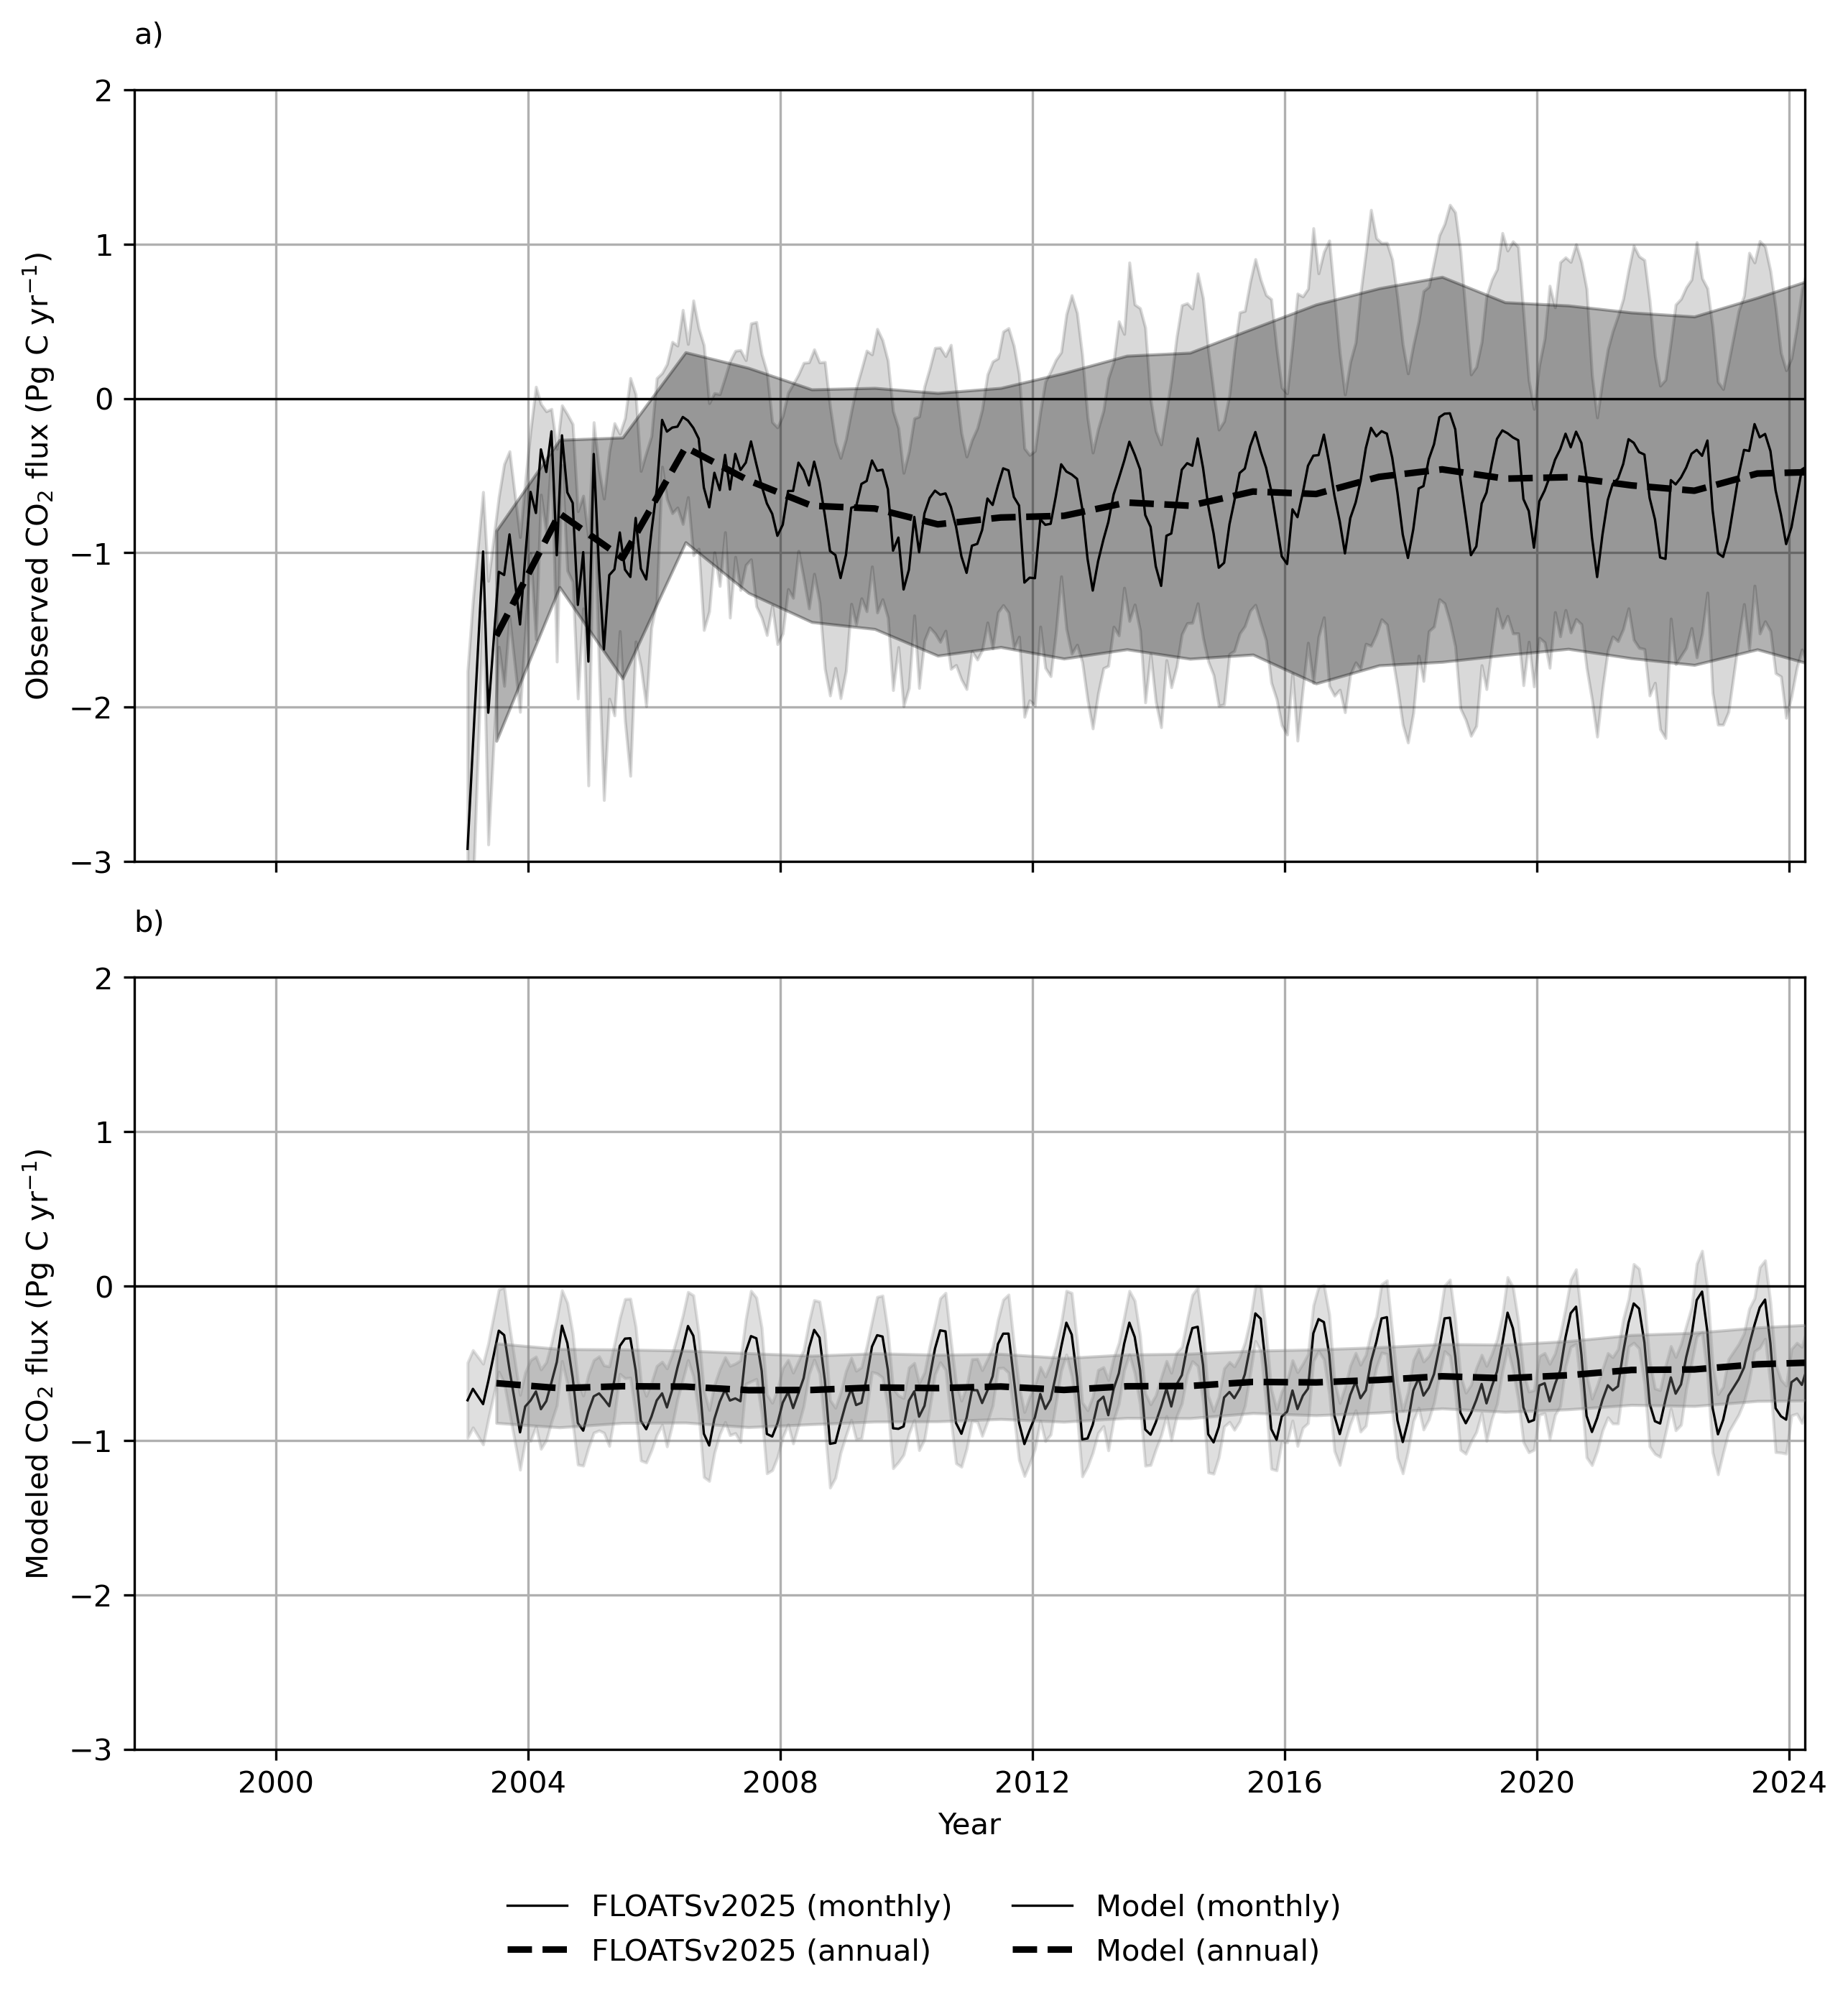

In [3]:
# ============================================================
# 12) PLOTTING (MONTHLY + ANNUAL, CLEAN 4-ITEM LEGEND)
# ============================================================
import matplotlib.pyplot as plt

# --- Create mid-year timestamps for annual plotting ---
yearly_flux_summary["year_center"] = pd.to_datetime(
    yearly_flux_summary["year"].astype(str) + "-07-01"
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 10), dpi=300, sharex=True,
    gridspec_kw={"hspace": 0.15}
)

time = monthly_flux_summary["date"]
year_time = yearly_flux_summary["year_center"]

# ---------------------------
# Panel (a): Observations
# ---------------------------

# Monthly mean
ax1.plot(
    time,
    monthly_flux_summary["floats"],
    label="FLOATSv2025 (monthly)",
    color="k",
    lw=0.8,
    zorder=3,
)

# Monthly ±σ
ax1.fill_between(
    time,
    monthly_flux_summary["floats"] - monthly_flux_summary["floats_sigma_PgC_yr"],
    monthly_flux_summary["floats"] + monthly_flux_summary["floats_sigma_PgC_yr"],
    color="k",
    alpha=0.15,
    zorder=2,
)

# Annual mean
ax1.plot(
    year_time,
    yearly_flux_summary["floats"],
    linestyle="--",
    color="k",
    lw=2.2,
    zorder=4,
    label="FLOATSv2025 (annual)",
)

# Annual ±σ
ax1.fill_between(
    year_time,
    yearly_flux_summary["floats"] - yearly_flux_summary["floats_sigma_PgC_yr"],
    yearly_flux_summary["floats"] + yearly_flux_summary["floats_sigma_PgC_yr"],
    color="k",
    alpha=0.30,
    zorder=3,
)

ax1.set_ylabel("Observed CO$_2$ flux (Pg C yr$^{-1}$)")
ax1.grid(True)
ax1.axhline(0, color="k", lw=0.8)

# ---------------------------
# Panel (b): Model predictions
# ---------------------------

# Monthly mean
ax2.plot(
    time,
    monthly_flux_summary["floats_predictions"],
    label="Model (monthly)",
    color="k",
    lw=0.8,
    zorder=3,
)

# Monthly ±σ 
ax2.fill_between(
    time,
    monthly_flux_summary["floats_predictions"] -
    monthly_flux_summary["floats_predictions_sigma_PgC_yr"],
    monthly_flux_summary["floats_predictions"] +
    monthly_flux_summary["floats_predictions_sigma_PgC_yr"],
    color="gray",
    alpha=0.25,
    zorder=2,
)

# Annual mean
ax2.plot(
    year_time,
    yearly_flux_summary["floats_predictions"],
    linestyle="--",
    color="k",
    lw=2.2,
    zorder=4,
    label="Model (annual)",
)

# Annual ±σ 
ax2.fill_between(
    year_time,
    yearly_flux_summary["floats_predictions"] -
    yearly_flux_summary["floats_predictions_sigma_PgC_yr"],
    yearly_flux_summary["floats_predictions"] +
    yearly_flux_summary["floats_predictions_sigma_PgC_yr"],
    color="gray",
    alpha=0.35,
    zorder=3,
)

ax2.set_xlabel("Year")
ax2.set_ylabel("Modeled CO$_2$ flux (Pg C yr$^{-1}$)")
ax2.grid(True)
ax2.axhline(0, color="k", lw=0.8)

# ---------------------------
# Final figure cosmetics
# ---------------------------

ax1.set_xlim(pd.Timestamp("1997-10-01"), pd.Timestamp("2024-03-31"))
ax2.set_xlim(pd.Timestamp("1997-10-01"), pd.Timestamp("2024-03-31"))

ax1.set_ylim(-3, 2)
ax2.set_ylim(-3, 2)

ax1.text(0, 1.06, "a)", transform=ax1.transAxes)
ax2.text(0, 1.06, "b)", transform=ax2.transAxes)

# ---- SINGLE CLEAN 4-ITEM LEGEND ----
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=[0, 0.07, 1, 1])

# ---------------------------
# SAVE + SHOW
# ---------------------------

fig.savefig(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/figs/"
    "floats-only_main_result_obs_vs_models_monthly_and_annual_PgCyr_MCuncertainty.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


In [4]:
# ============================================================
# === LINEAR TRENDS (FLOATS OBS vs MODEL, 2003–2024) ========
# ============================================================

from scipy.stats import linregress
import numpy as np

# ============================================
# 1) SELECT PERIOD
# ============================================

mask = (yearly_flux_summary["year"] >= 2003) & (yearly_flux_summary["year"] <= 2024)

years = yearly_flux_summary.loc[mask, "year"].values

floats_flux = yearly_flux_summary.loc[mask, "floats"].values
pred_flux   = yearly_flux_summary.loc[mask, "floats_predictions"].values

# ============================================
# 2) LINEAR REGRESSIONS
# ============================================

# --- FLOATS OBS ---
slope_floats, intercept, r, p_floats, stderr_floats = linregress(years, floats_flux)

# --- FLOATS MODEL ---
slope_pred, intercept, r, p_pred, stderr_pred = linregress(years, pred_flux)

# ============================================
# 3) REPORT
# ============================================

print("\n=== Linear Trends (FLOATS, 2003–2024) ===\n")

print(
    f"FLOATS observed trend:  "
    f"{slope_floats:.4f} ± {stderr_floats:.4f} Pg C yr⁻² "
    f"(p = {p_floats:.2e})"
)

print(
    f"FLOATS model trend:     "
    f"{slope_pred:.4f} ± {stderr_pred:.4f} Pg C yr⁻² "
    f"(p = {p_pred:.2e})"
)



=== Linear Trends (FLOATS, 2003–2024) ===

FLOATS observed trend:  0.0219 ± 0.0070 Pg C yr⁻² (p = 5.26e-03)
FLOATS model trend:     0.0071 ± 0.0010 Pg C yr⁻² (p = 4.88e-07)
